# Домашнее задание №7

In [27]:
!pip install numpy pandas matplotlib seaborn scikit-learn scikit-learn-extra

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn_extra.cluster import KMedoids

In [3]:
DATA_PATH = "MainDataset.csv"
data_cluster = pd.read_csv(DATA_PATH)

In [12]:
X = data_cluster.drop(['Id', 'y'], axis=1)

y_true = data_cluster['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Обработка пропусков
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    median_val = X[col].median()
    X.loc[:, col] = X[col].fillna(median_val)

categorical_cols = X.select_dtypes(include=['category', 'object']).columns
for col in categorical_cols:
    if not X[col].mode().empty:
        mode_val = X[col].mode()[0]
    else:
        mode_val = 'unknown'
    X.loc[:, col] = X[col].fillna(mode_val)

numeric_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

for col in numeric_features:
        if col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Находим индексы выбросов
            outlier_indices = X[(X[col] < lower_bound) | (X[col] > upper_bound)].index
            
            print(f"{col}: {len(outlier_indices)} выбросов ({len(outlier_indices)/len(X)*100:.2f}%)")
            
            # Заменяем выбросы граничными значениями
            X.loc[X[col] < lower_bound, col] = lower_bound
            X.loc[X[col] > upper_bound, col] = upper_bound

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X.loc[:, col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


age: 489 выбросов (1.08%)
balance: 4729 выбросов (10.46%)
duration: 3235 выбросов (7.16%)
campaign: 3064 выбросов (6.78%)
pdays: 8257 выбросов (18.26%)
previous: 8257 выбросов (18.26%)


Понизим размерность с помощью PCA

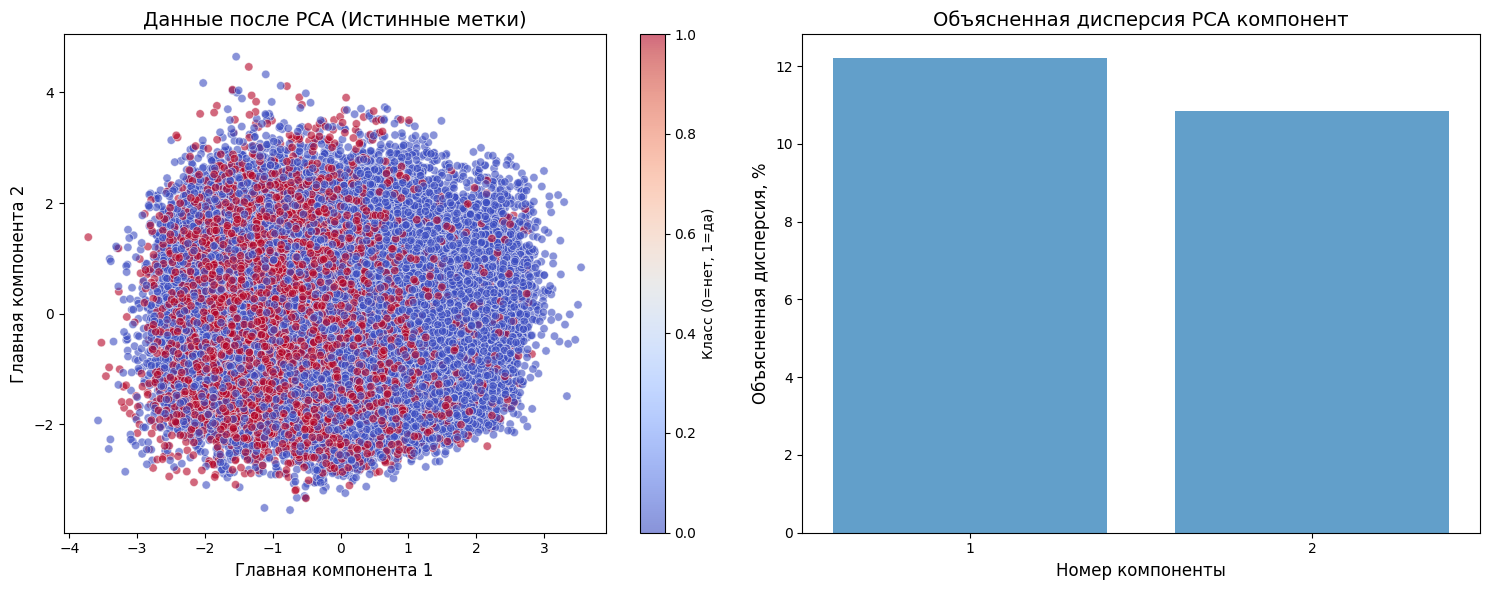

In [47]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['true_label'] = y_true.values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Визуализация по истинным меткам
scatter1 = axes[0].scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['true_label'], 
                           cmap='coolwarm', alpha=0.6, edgecolors='w', linewidth=0.5)
axes[0].set_title('Данные после PCA (Истинные метки)', fontsize=14)
axes[0].set_xlabel('Главная компонента 1', fontsize=12)
axes[0].set_ylabel('Главная компонента 2', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Класс (0=нет, 1=да)')

# Визуализация распределения по компонентам
axes[1].bar(range(1, 3), pca.explained_variance_ratio_ * 100, alpha=0.7)
axes[1].set_title('Объясненная дисперсия PCA компонент', fontsize=14)
axes[1].set_xlabel('Номер компоненты', fontsize=12)
axes[1].set_ylabel('Объясненная дисперсия, %', fontsize=12)
axes[1].set_xticks([1, 2])

plt.tight_layout()
plt.show()

Кластеризация KMeans

Silhouette Score (KMeans): 0.0938
Adjusted Rand Index (KMeans): -0.0468
Normalized Mutual Info (KMeans): 0.0263
Размеры кластеров (KMeans): [14167 31044]


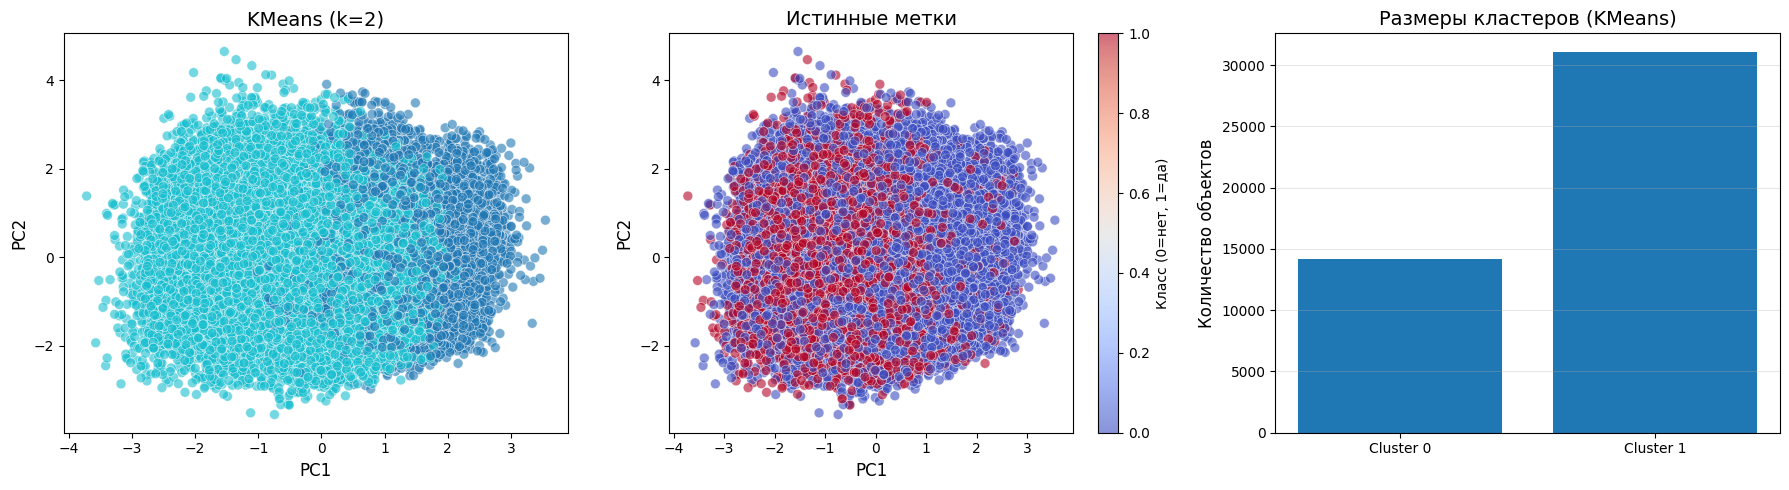

In [46]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Вычисляем метрики для KMeans
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
ari_kmeans = adjusted_rand_score(y_true, kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(y_true, kmeans_labels)

print(f"Silhouette Score (KMeans): {silhouette_kmeans:.4f}")
print(f"Adjusted Rand Index (KMeans): {ari_kmeans:.4f}")
print(f"Normalized Mutual Info (KMeans): {nmi_kmeans:.4f}")
print(f"Размеры кластеров (KMeans): {np.bincount(kmeans_labels)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. KMeans с k=2
axes[0].scatter(pca_df['PC1'], pca_df['PC2'], c=kmeans_labels, cmap='tab10', 
                alpha=0.6, edgecolors='w', linewidth=0.5, s=50)
axes[0].set_title(f'KMeans (k=2)', fontsize=14)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)

# 2. Истинные метки для сравнения
scatter2 = axes[1].scatter(pca_df['PC1'], pca_df['PC2'], c=y_true, cmap='coolwarm', 
                alpha=0.6, edgecolors='w', linewidth=0.5, s=50)
axes[1].set_title('Истинные метки', fontsize=14)
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Класс (0=нет, 1=да)')

# 3. Гистограмма распределения по кластерам
cluster_counts = np.bincount(kmeans_labels)

axes[2].bar(
    ['Cluster 0', 'Cluster 1'],
    cluster_counts
)
axes[2].set_title('Размеры кластеров (KMeans)', fontsize=14)
axes[2].set_ylabel('Количество объектов', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Кластеризация DBSCAN

DBSCAN: clusters=6, noise=2840 (6.3%)

Оценка качества:
Silhouette (без шума): 0.087
Adjusted Rand Index: 0.008
Normalized Mutual Info: 0.018


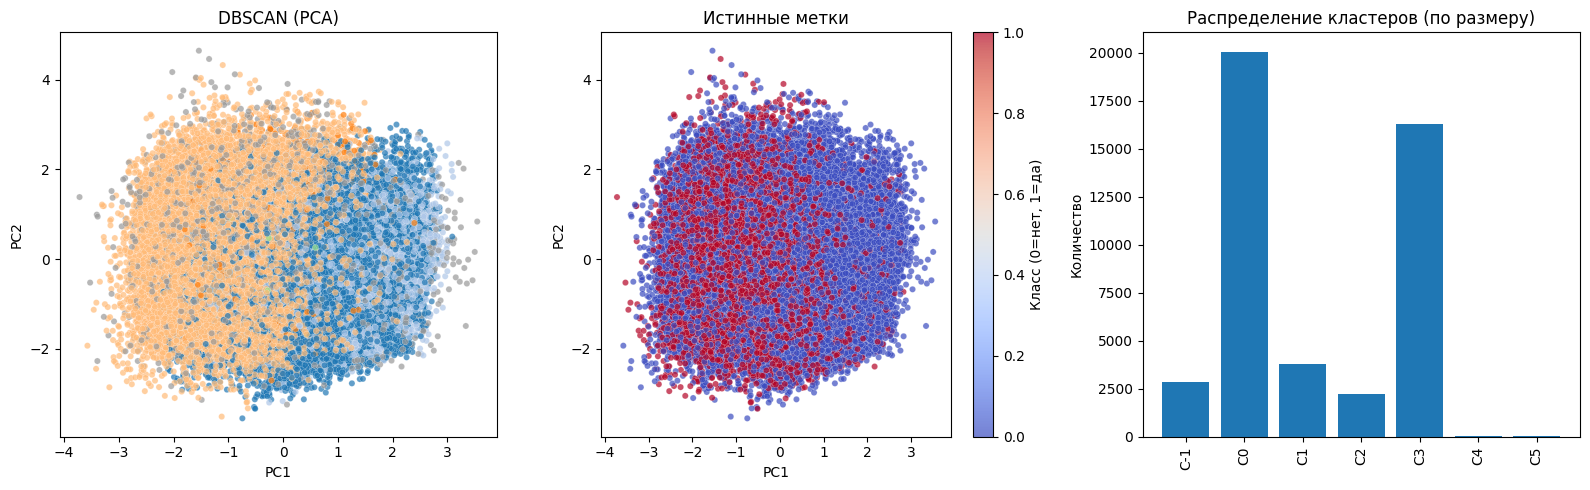

In [42]:
dbscan = DBSCAN(eps=2.0, min_samples=16)
dbscan_labels = dbscan.fit_predict(X_scaled)

y_true_var = y_true

unique_labels = np.unique(dbscan_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = np.sum(dbscan_labels == -1)
noise_pct = n_noise / len(dbscan_labels) * 100

print(f"DBSCAN: clusters={n_clusters}, noise={n_noise} ({noise_pct:.1f}%)")

print("\nОценка качества:")
# Silhouette
valid_mask = dbscan_labels != -1
valid_labels = dbscan_labels[valid_mask]
if valid_mask.sum() > 1 and len(np.unique(valid_labels)) > 1:
    sil = silhouette_score(X_scaled[valid_mask], valid_labels)
    print(f"Silhouette (без шума): {sil:.3f}")
else:
    print("Silhouette (без шума): N/A (недостаточно кластеров)")

# ARI и NMI относительно истинных меток
ari = adjusted_rand_score(y_true_var, dbscan_labels)
nmi = normalized_mutual_info_score(y_true_var, dbscan_labels)
print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Info: {nmi:.3f}")

# Подготовка цветов: серый для шума (-1), палитра для остальных
palette = sns.color_palette('tab20', n_colors=max(1, len(unique_labels)))
colors = []
for lbl in dbscan_labels:
    if lbl == -1:
        colors.append((0.6, 0.6, 0.6))
    else:
        colors.append(palette[int(lbl) % len(palette)])

# Визуализация: PCA, истинные метки и распределение кластеров
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) DBSCAN на PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=20, edgecolors='w', linewidth=0.2, alpha=0.7)
axes[0].set_title('DBSCAN (PCA)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# 2) Истинные метки
scatter3 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true_var, cmap='coolwarm', s=20, edgecolors='w', linewidth=0.2, alpha=0.7)
axes[1].set_title('Истинные метки')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[1], label='Класс (0=нет, 1=да)')

# 3) Гистограмма распределения кластеров
unique_db, counts_db = np.unique(dbscan_labels, return_counts=True)
order = np.argsort(-counts_db)
max_bars = 20
if len(unique_db) > max_bars:
    top_idx = order[:max_bars-1]
    top_labels = unique_db[top_idx]
    top_counts = counts_db[top_idx]
    other_count = counts_db.sum() - top_counts.sum()
    plot_labels = np.append(top_labels, -999)   # -999 -> 'Другие'
    plot_counts = np.append(top_counts, other_count)
    plot_labels_str = [f'C{int(l)}' if l != -999 else 'Другие' for l in plot_labels]
else:
    plot_labels_str = [f'C{int(l)}' for l in unique_db]
    plot_counts = counts_db

axes[2].bar(range(len(plot_counts)), plot_counts)
axes[2].set_xticks(range(len(plot_counts)))
axes[2].set_xticklabels(plot_labels_str, rotation=90)
axes[2].set_title('Распределение кластеров (по размеру)')
axes[2].set_ylabel('Количество')

plt.tight_layout()
plt.show()

MiniBatch KMeans

MiniBatch K-Means
Silhouette Score: 0.0927
Adjusted Rand Index: 0.0149
Normalized Mutual Info: 0.0182
Размеры кластеров: [23784 21427]


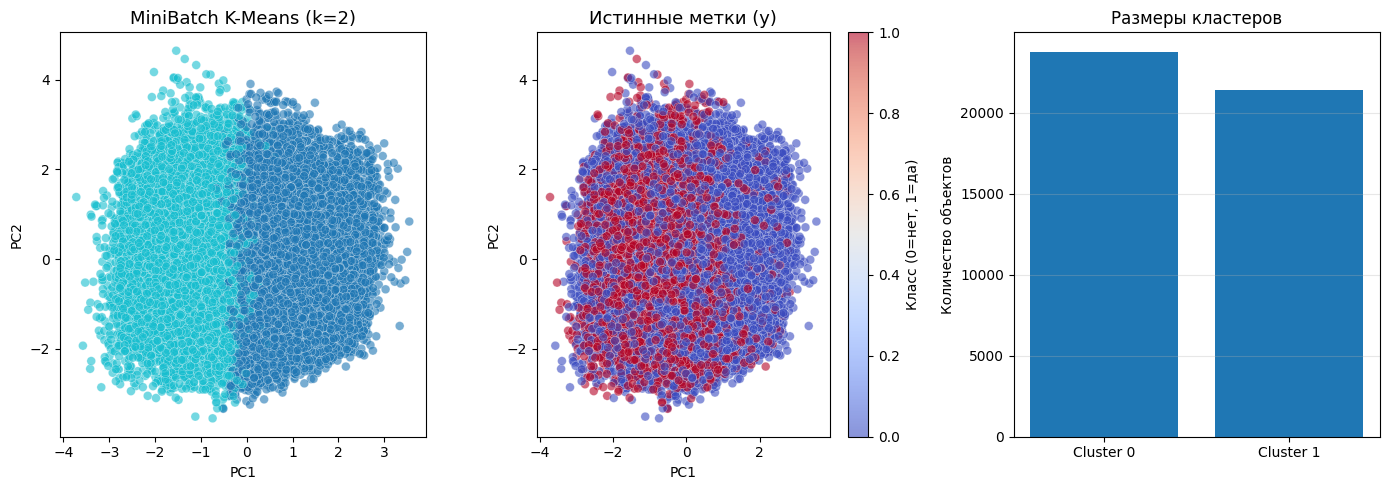

In [48]:
k = 2
mbk = MiniBatchKMeans(
    n_clusters=k,
    batch_size=1024,
    n_init=10,
    max_iter=100,
    random_state=42
)

mbk_labels = mbk.fit_predict(X_scaled)

# Метрики
silhouette_mbk = silhouette_score(X_scaled, mbk_labels)
ari_mbk = adjusted_rand_score(y_true, mbk_labels)
nmi_mbk = normalized_mutual_info_score(y_true, mbk_labels)

print("MiniBatch K-Means")
print(f"Silhouette Score: {silhouette_mbk:.4f}")
print(f"Adjusted Rand Index: {ari_mbk:.4f}")
print(f"Normalized Mutual Info: {nmi_mbk:.4f}")
print(f"Размеры кластеров: {np.bincount(mbk_labels)}")

# PCA
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# MiniBatch K-Means
axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=mbk_labels,
    cmap='tab10',
    alpha=0.6,
    edgecolors='w',
    linewidth=0.3,
    s=40
)
axes[0].set_title(
    f'MiniBatch K-Means (k={k})',
    fontsize=13
)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Истинные метки
scatter4 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_true,
    cmap='coolwarm',
    alpha=0.6,
    edgecolors='w',
    linewidth=0.3,
    s=40
)
axes[1].set_title('Истинные метки (y)', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter4, ax=axes[1], label='Класс (0=нет, 1=да)')

cluster_counts = np.bincount(mbk_labels)
axes[2].bar(['Cluster 0', 'Cluster 1'], cluster_counts)
axes[2].set_title('Размеры кластеров')
axes[2].set_ylabel('Количество объектов')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Выводы

Кластеризация алгоритмами KMeans, MiniBatch KMeans и DBSCAN показала низкие значения Silhouette (≈0.09) и практически нулевые значения ARI и NMI относительно истинных меток. На всех диаграммах видно, что кластеры имеют сильное перекрытие и слабо отделимы. Это свидетельствует в первую очередь о слабой связности параметров между собой. Целевая метка плохо предсказуема методами кластеризации.

Не смотря на то, что каждый метод создал уникальное в смысле пропорции разбиение на кластеры, а KMeans даже отразил несбалансированность классов, соответствие истинным меткам у всех методов крайне низкое (скорее похоже на случайное совпадение), что свидетельствует о неэффективности методов кластеризации в конкретной задаче классификации.